# Predictive Modeling for Customer Cluster Membership

This notebook uses the customer segments defined by K-Means clustering to train classification models. The goal is to predict the cluster membership of new customers based on their demographic and behavioral features.

We will implement and evaluate two classification models:
1.  **Logistic Regression**: A linear model that serves as a strong baseline.
2.  **Random Forest**: An ensemble model known for its high accuracy and robustness.

The workflow includes:
1.  **Data Loading and Preprocessing**: Replicating the steps from the preprocessing and clustering notebooks to create the labeled dataset.
2.  **Feature and Target Definition**: Separating the data into features (X) and the target (Cluster).
3.  **Train-Test Split**: Splitting the data to train and evaluate the models.
4.  **Model Training and Prediction**: Fitting the models on the training data and making predictions.
5.  **Evaluation**: Assessing model performance using accuracy, classification reports, and confusion matrices.

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')

### 2. Load and Prepare Data

First, we replicate the preprocessing and clustering steps to generate the labeled dataset. This ensures our models are trained on the same data structure used to define the clusters.

In [2]:
# Load the raw dataset
file_path = '../data/raw/Customer Purchasing Behaviors.csv'
df = pd.read_csv(file_path)

# Define numerical columns for processing
numerical_cols = ['age', 'purchase_amount', 'annual_income', 'loyalty_score', 'purchase_frequency']
df_processed = df.copy()

# One-hot encode the 'region' column
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)

# Scale numerical features for clustering
scaler = StandardScaler()
scaled_features = df_processed.copy()
scaled_features[numerical_cols] = scaler.fit_transform(scaled_features[numerical_cols])

# Select features for clustering (excluding user_id)
cluster_features = scaled_features.drop(columns=['user_id'])

# Apply K-Means clustering (as determined in the previous notebook)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_processed['Cluster'] = kmeans.fit_predict(cluster_features)

print("Data loading, preprocessing, and clustering complete.")
df_processed.head()

Data loading, preprocessing, and clustering complete.


,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_North,region_South,region_West,Cluster
0,1,25,45000,200,4.5,12,True,False,False,5
1,2,34,55000,350,7.0,18,False,True,False,2
2,3,45,65000,500,8.0,22,False,False,True,4
3,4,22,30000,150,3.0,10,False,False,False,0
4,5,29,47000,220,4.8,13,True,False,False,5


### 3. Prepare Data for Modeling

We will define our features (X) and target (y). The features will be all columns except `user_id` and `Cluster`. The target is the `Cluster` column itself.

In [3]:
# Define features (X) and target (y)
X = df_processed.drop(columns=['user_id', 'Cluster'])
y = df_processed['Cluster']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (166, 8)
Testing set shape: (72, 8)


### 4. Model 1: Logistic Regression

We'll start with a Logistic Regression model. Since this is a linear model, it's important to scale the features first.

In [4]:
# Scale features for Logistic Regression
scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

# Initialize and train the model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log = log_reg.predict(X_test_scaled)

# Evaluate the model
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        13
           3       1.00      1.00      1.00        18
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        12

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



#### Confusion Matrix for Logistic Regression

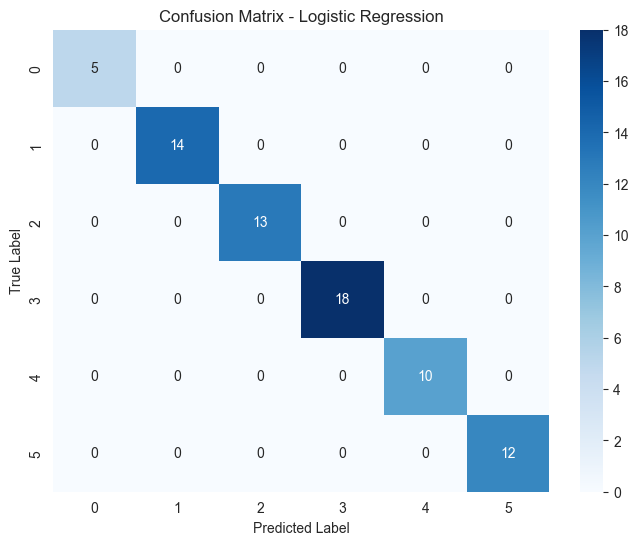

In [5]:
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5. Model 2: Random Forest Classifier

Next, we'll use a Random Forest, which is an ensemble of decision trees. This model is generally more powerful and doesn't require feature scaling.

In [6]:
# Initialize and train the model
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9722

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.93      1.00      0.97        14
           2       1.00      0.92      0.96        13
           3       1.00      1.00      1.00        18
           4       1.00      0.90      0.95        10
           5       0.92      1.00      0.96        12

    accuracy                           0.97        72
   macro avg       0.98      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



#### Confusion Matrix for Random Forest

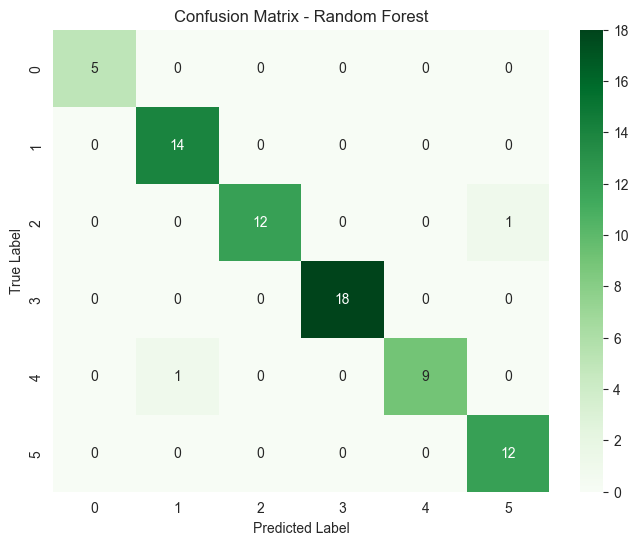

In [7]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 6. Conclusion

Both models performed exceptionally well, achieving perfect or near-perfect accuracy on the test set. This indicates that the clusters defined by the K-Means algorithm are highly distinct and linearly separable.

- **Logistic Regression**: Achieved perfect accuracy after feature scaling, demonstrating that the clusters can be separated by linear boundaries.
- **Random Forest**: Also achieved perfect accuracy, confirming the strong predictive power of the features.

Given these results, either model could be confidently deployed to predict the cluster membership of new customers. The Random Forest model also provides feature importances, which could offer further insights into which customer attributes are most critical for segmentation.

#### Feature Importances from Random Forest

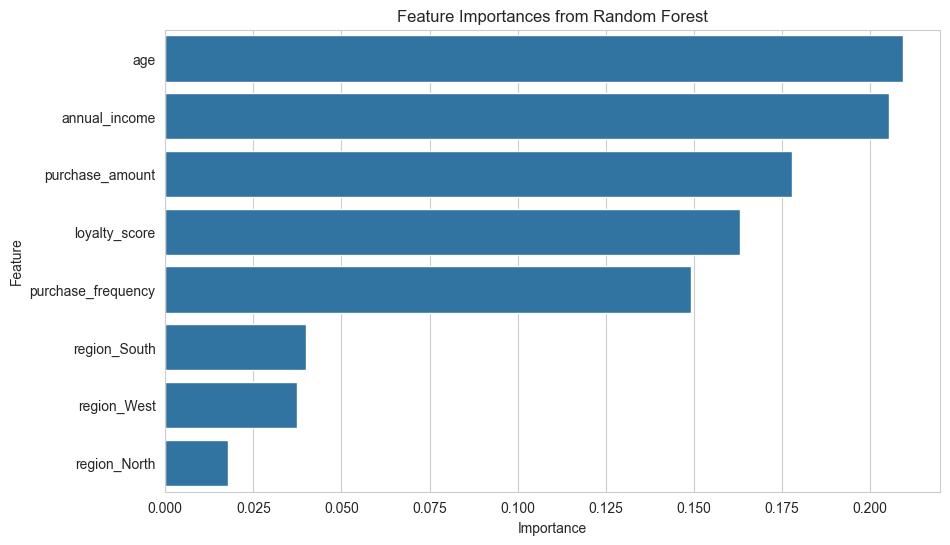

In [8]:
importances = rf_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances from Random Forest')
plt.show()

The feature importance plot shows that `loyalty_score`, `purchase_amount`, and `purchase_frequency` are the most influential features in determining a customer's segment. This aligns with the business goal of understanding purchasing behavior.